In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('/content/student-records-ballotte-dance-academy-puchong-20260909123611.xlsx')

In [6]:
df.head()

,Student Name,Student Alias,Student Picture,Student ID,IC No.,Passport No.,Passport Expiry Date,Citizenship,Gender,Race,...,Previous Schools 3: From,Previous Schools 3: To,Previous Schools 3: Level,Previous Schools 3: Age,Start Date,End Date,Pickup Vehicle Info.,Pickup Persons,Other Files,Updated
0,KWEK JUN XING,NaN,NaN,42,170130160080,NaN,NaN,Malaysia,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04-Sep-2026 14:10
1,Kwek Jun Xiu,NaN,NaN,41,220228160022,NaN,NaN,Malaysia,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04-Sep-2026 14:09
2,Ziyan Niu (Emma),NaN,NaN,40,EL6846418,NaN,NaN,China,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03-Sep-2026 23:20
3,Carina,NaN,NaN,39,EJ7841074,NaN,NaN,China,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29-Aug-2026 12:22
4,Adelynn Gan Ker Wei,NaN,NaN,38,220607101786,NaN,NaN,Malaysian,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-Aug-2026 22:30


In [11]:
# Check dataset size and column names
print("Dataset shape:", df.shape)

for col in df.columns:
    print(col)

Dataset shape: (99, 93)
Student Name
Student Alias
Student Picture
Student ID
IC No.
Passport No.
Passport Expiry Date
Citizenship
Gender
Race
Religion
Date of Birth
Place of Birth
Birth Cert. No.
Birth Cert.
Address
Email
Mobile
Guardians 1: Name
Guardians 1: Alias
Guardians 1: IC
Guardians 1: Relationship
Guardians 1: Company
Guardians 1: Occupation
Guardians 1: Mobile
Guardians 1: Email
Guardians 2: Name
Guardians 2: Alias
Guardians 2: IC
Guardians 2: Relationship
Guardians 2: Company
Guardians 2: Occupation
Guardians 2: Mobile
Guardians 2: Email
Guardians 3: Name
Guardians 3: Alias
Guardians 3: IC
Guardians 3: Relationship
Guardians 3: Company
Guardians 3: Occupation
Guardians 3: Mobile
Guardians 3: Email
Emergency Contacts 1: Name
Emergency Contacts 1: Relationship
Emergency Contacts 1: Mobile
Emergency Contacts 2: Name
Emergency Contacts 2: Relationship
Emergency Contacts 2: Mobile
Emergency Contacts 3: Name
Emergency Contacts 3: Relationship
Emergency Contacts 3: Mobile
Emergenc

In [12]:
# Check missing values and percentage
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary.sort_values(
    'Missing_Percentage',
    ascending=False
)

,Missing_Count,Missing_Percentage
Student Alias,99,100.00
Student Picture,99,100.00
Religion,99,100.00
Passport Expiry Date,99,100.00
Passport No.,99,100.00
...,...,...
Date of Birth,2,2.02
Gender,2,2.02
Student Name,0,0.00
Student ID,0,0.00


In [13]:
# Identify completely empty and usable columns
empty_columns = df.columns[df.isnull().all()].tolist()
usable_columns = df.columns[~df.isnull().all()].tolist()

print("Completely empty columns:", len(empty_columns))
print("Usable columns:", len(usable_columns))

print("\nUsable Columns:")
for col in usable_columns:
    print(col)

Completely empty columns: 76
Usable columns: 17

Usable Columns:
Student Name
Student ID
IC No.
Citizenship
Gender
Date of Birth
Birth Cert.
Address
Email
Mobile
Guardians 1: Name
Guardians 1: Mobile
Guardians 1: Email
Guardians 2: Name
Guardians 2: Mobile
Guardians 2: Email
Updated


In [14]:
# Select variables required for analysis
student_df = df[
    [
        'Student ID',
        'Citizenship',
        'Gender',
        'Date of Birth',
        'Address',
        'Updated'
    ]
].copy()

student_df.head()

,Student ID,Citizenship,Gender,Date of Birth,Address,Updated
0,42,Malaysia,Female,30-Jan-2017,No.6 Jalan Tasik Prima 3/2 Taman Tasik Prima,04-Sep-2026 14:10
1,41,Malaysia,Female,28-Feb-2022,No.6 Jalan Tasik Prima 3/2 Taman Tasik Prima,04-Sep-2026 14:09
2,40,China,Female,03-Feb-2018,"Epic A,jalan bp 7/12, bukit bandar puchong 2, ...",03-Sep-2026 23:20
3,39,China,Female,02-Feb-2021,cyberjaya,29-Aug-2026 12:22
4,38,Malaysian,Female,07-Jun-2022,"19, JALAN PP 1/6, TAMAN PUTRA PRIMA, 47130, PU...",25-Aug-2026 22:30


In [15]:
# Check duplicate Student IDs
print("Total rows:", len(student_df))
print("Unique Student IDs:", student_df['Student ID'].nunique())
print("Duplicate Student IDs:", student_df['Student ID'].duplicated().sum())

Total rows: 99
Unique Student IDs: 99
Duplicate Student IDs: 0


In [16]:
# Display duplicate Student IDs
student_df[
    student_df['Student ID'].duplicated(keep=False)
].sort_values('Student ID')

,Student ID,Citizenship,Gender,Date of Birth,Address,Updated


In [17]:
# Check missing values in selected variables
missing_values = pd.DataFrame({
    'Missing_Count': student_df.isnull().sum(),
    'Missing_Percentage': (student_df.isnull().sum() / len(student_df) * 100).round(2)
})

missing_values

,Missing_Count,Missing_Percentage
Student ID,0,0.00
Citizenship,18,18.18
Gender,2,2.02
Date of Birth,2,2.02
Address,6,6.06
Updated,0,0.00


In [19]:
# Handle missing categorical values
student_df['Citizenship'] = student_df['Citizenship'].fillna('Unknown')
student_df['Gender'] = student_df['Gender'].fillna('Unknown')
student_df['Address'] = student_df['Address'].fillna('Unknown')

In [22]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student ID     99 non-null     int64 
 1   Citizenship    99 non-null     object
 2   Gender         99 non-null     object
 3   Date of Birth  97 non-null     object
 4   Address        99 non-null     object
 5   Updated        99 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


In [23]:
student_df['Date of Birth'] = pd.to_datetime(     student_df['Date of Birth'],     errors='coerce' )

In [24]:
# Check unique values for categorical variables
print("Citizenship:")
print(student_df['Citizenship'].value_counts(dropna=False))

print("\nGender:")
print(student_df['Gender'].value_counts(dropna=False))

Citizenship:
Citizenship
Malaysian     46
Unknown       18
Malaysia      12
Malaysia       5
China          4
MALAYSIAN      4
malaysian      2
Malaysian      2
Chinese        2
Brazilian      1
Cn             1
MALAYSIA       1
Japanese       1
Name: count, dtype: int64

Gender:
Gender
Female     97
Unknown     2
Name: count, dtype: int64


In [31]:
# Standardize Citizenship values
citizenship_mapping = {
    'Malaysian': 'Malaysian',
    'Malaysian ': 'Malaysian',
    'Malaysia': 'Malaysian',
    'Malaysia ': 'Malaysian',
    'MALAYSIAN': 'Malaysian',
    'MALAYSIA ': 'Malaysian',
    'malaysian': 'Malaysian',
    'China': 'Chinese',
    'Chinese': 'Chinese',
    'Cn': 'Chinese',
    'Brazilian': 'Brazilian',
    'Japanese': 'Japanese',
    'Unknown': 'Unknown'
}

student_df['Citizenship'] = student_df['Citizenship'].replace(citizenship_mapping)

In [32]:
# Verify standardized Citizenship values
student_df['Citizenship'].value_counts()

,count
Citizenship,
Malaysian,72
Unknown,18
Chinese,7
Brazilian,1
Japanese,1


In [33]:
# Check Date of Birth range
print("Earliest DOB:", student_df['Date of Birth'].min())
print("Latest DOB:", student_df['Date of Birth'].max())

# Preview DOB values
student_df[['Student ID', 'Date of Birth']].sort_values('Date of Birth').head(10)

Earliest DOB: 1975-09-06 00:00:00
Latest DOB: 2024-06-05 00:00:00


,Student ID,Date of Birth
9,34,1975-09-06
51,2023008,1992-01-15
52,2023035,1992-07-12
26,30,1997-01-22
13,33,2001-10-28
12,23,2011-03-24
81,2025138,2012-09-20
83,2023041,2014-03-05
82,2023034,2014-06-17
32,26,2014-08-09


In [34]:
# Check most recent DOB values
student_df[['Student ID', 'Date of Birth']].sort_values(
    'Date of Birth',
    ascending=False
).head(10)

,Student ID,Date of Birth
5,36,2024-06-05
42,22,2023-06-11
46,18,2023-04-19
40,25,2023-03-28
24,31,2023-01-19
58,10,2023-01-03
76,2025159,2022-10-17
57,11,2022-10-05
28,29,2022-06-19
56,13,2022-06-18


In [36]:
# Calculate student age as of 10 September 2026
reference_date = pd.Timestamp('2026-09-10')

student_df['Age'] = (
    reference_date.year - student_df['Date of Birth'].dt.year
    - (
        (reference_date.month < student_df['Date of Birth'].dt.month)
        | (
            (reference_date.month == student_df['Date of Birth'].dt.month)
            & (reference_date.day < student_df['Date of Birth'].dt.day)
        )
    )
).astype('Int64')

# Preview calculated Age
student_df[['Student ID', 'Date of Birth', 'Age']].head()

,Student ID,Date of Birth,Age
0,42,2017-01-30,9
1,41,2022-02-28,4
2,40,2018-02-03,8
3,39,2021-02-02,5
4,38,2022-06-07,4


In [37]:
# Check Age distribution
student_df['Age'].value_counts(dropna=False).sort_index()

,count
Age,
2,1
3,7
4,15
5,23
6,15
7,7
8,10
9,5
10,3


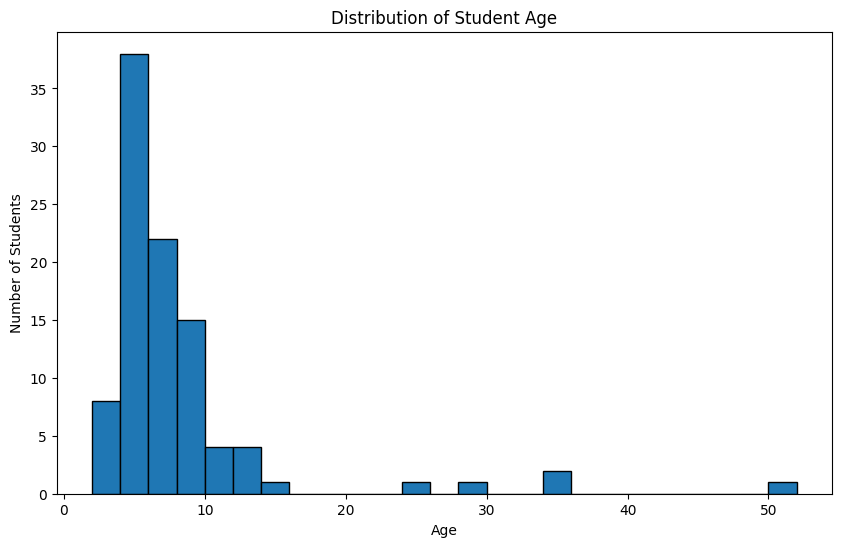

In [38]:
# Plot histogram of student Age
plt.figure(figsize=(10, 6))

plt.hist(
    student_df['Age'].dropna(),
    bins=range(
        int(student_df['Age'].min()),
        int(student_df['Age'].max()) + 2,
        2
    ),
    edgecolor='black'
)

plt.title('Distribution of Student Age')
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.show()

In [39]:
# Create Age Group
bins = [0, 3, 6, 9, 12, 17, float('inf')]
labels = ['0–3', '4–6', '7–9', '10–12', '13–17', 'Adult']

student_df['Age Group'] = pd.cut(
    student_df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

student_df['Age Group'] = (
    student_df['Age Group']
    .cat.add_categories('Unknown')
    .fillna('Unknown')
)

# Verify Age Group
student_df['Age Group'].value_counts(sort=False)

,count
Age Group,
0–3,8
4–6,53
7–9,22
10–12,7
13–17,2
Adult,5
Unknown,2


In [40]:
# Display Address values
pd.set_option('display.max_colwidth', None)

student_df[['Student ID', 'Address']].head(30)

,Student ID,Address
0,42,No.6 Jalan Tasik Prima 3/2 Taman Tasik Prima
1,41,No.6 Jalan Tasik Prima 3/2 Taman Tasik Prima
2,40,"Epic A,jalan bp 7/12, bukit bandar puchong 2, 47120 puchong selangor"
3,39,cyberjaya
4,38,"19, JALAN PP 1/6, TAMAN PUTRA PRIMA, 47130, PUCHONG, SEL"
5,36,32 jalan timur 2 disland residence puchong
6,35,"No.5, Jalan PP 4/11, Taman Putra Prima, 47130 Puchong Selangor"
7,2024075,"17, JALAN NPT 7/1D, TAMAN NUSAPUTRA TIMUR 47130 PUCHONG SELANGOR"
8,2023032,Unknown
9,34,"H-14-03 Desa Impiana, Jalan Prima Utama 2/1, Taman Puchong Prima"


In [41]:
# Extract 5-digit postcode from Address
student_df['Postcode'] = (
    student_df['Address']
    .str.extract(r'\b(\d{5})\b')[0]
)

# Replace missing postcodes with Unknown
student_df['Postcode'] = student_df['Postcode'].fillna('Unknown')

# Verify extracted Postcode values
student_df['Postcode'].value_counts()

,count
Postcode,
Unknown,30
47120,19
63000,15
47100,12
47130,11
47150,6
47160,1
43800,1
63100,1


In [42]:
# Display all unique addresses for geographic review
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

student_df[['Student ID', 'Address']].drop_duplicates().sort_values('Address')

,Student ID,Address
22,24,"1-22-08, VERDI ECODOMINIUM, SYMPHONY HILLS, 63000, CYBERJAYA, SELANGOR."
33,2025166,"10, Jalan Abadi 1/14, Abadi heights, 47120 Puchong selangor"
95,2024078,"10, Jalan Sejati 2B, Sejati Residences, Persiaran Bestari, 63000 Cyberjaya Selangor"
92,2024088,"101, Jalan BP 14/4, Bandar Bukit Puchong 2, 47120 Puchong, Selangor."
46,18,"106 Jalan Tasik Prima 3/1_x000d_\nTaman Tasik Prima, puchong."
58,10,"11, JALAN BK3/10A, BANDAR KINRARA,47180 PUCHONG, SELANGOR."
91,2024099,"11, Jalan Prima 7/15,\nTaman Puchong Prima"
48,2023007,"112 , Jalan BP 14/4, Bandar Bukit Puchong 2, 47120 Puchong , Selangor"
28,29,"13-13A Jalan Saville , Saville D’lake , 47130 Puchong Selangor"
68,2025133,"15 Jalan PU1/5, 47140 Puchong"


In [47]:
# Create lowercase address for Area / Township matching
address_lower = student_df['Address'].str.lower()

# Create Area / Township
conditions = [
    address_lower.str.contains('cyberjaya|cyverjaya|cyber 1|cyber 9|cyber 10|cyber 11', na=False),
    address_lower.str.contains('putra prima|x2 residency', na=False),
    address_lower.str.contains('bandar bukit puchong|bukit bandar puchong|bukit puchong', na=False),
    address_lower.str.contains('puchong prima', na=False),
    address_lower.str.contains('putra impiana', na=False),
    address_lower.str.contains('puchong perdana', na=False),
    address_lower.str.contains('bandar kinrara', na=False),
    address_lower.str.contains('tasik prima', na=False),
    address_lower.str.contains('bandar 16 sierra|bdr 16 sierra', na=False),
    address_lower.str.contains('putra perdana', na=False),
    address_lower.str.contains('meranti jaya', na=False),
    address_lower.str.contains("d'island|disland", na=False),
    address_lower.str.contains('pusat bandar puchong', na=False),
    address_lower.str.contains('taman mas', na=False),
    address_lower.str.contains('puchong tekali', na=False),
    address_lower.str.contains('abadi heights', na=False),
    address_lower.str.contains('kipark', na=False),
    address_lower.str.contains('nusaputra', na=False),
    address_lower.str.contains('puchong utama', na=False),
    address_lower.str.contains('shorea park', na=False),
    address_lower.str.contains('kampung bersatu', na=False),
    address_lower.str.contains('tasik puchong', na=False),
    address_lower.str.contains('jalan puteri|the cruise residence', na=False),
    address_lower.str.contains('impian heights', na=False),
    address_lower.str.contains("saville d'lake|saville", na=False),
    address_lower.str.contains(r'jalan pu\d|jalan pu ', na=False, regex=True),
    address_lower.str.contains('dengkil', na=False),
    address_lower.str.contains('sepang', na=False)
]

areas = [
    'Cyberjaya',
    'Taman Putra Prima',
    'Bandar Bukit Puchong',
    'Taman Puchong Prima',
    'Taman Putra Impiana',
    'Taman Puchong Perdana',
    'Bandar Kinrara',
    'Taman Tasik Prima',
    'Bandar 16 Sierra',
    'Putra Perdana',
    'Taman Meranti Jaya',
    "D'Island",
    'Pusat Bandar Puchong',
    'Taman Mas',
    'Taman Puchong Tekali',
    'Abadi Heights',
    'Taman Kipark Puchong',
    'Taman Nusaputra',
    'Taman Puchong Utama',
    'Shorea Park',
    'Kampung Bersatu',
    'Taman Tasik Puchong',
    'Bandar Puteri Puchong',
    'Impian Heights',
    "Saville D'Lake",
    'Taman Puchong Utama',
    'Dengkil',
    'Sepang'
]

student_df['Area / Township'] = np.select(
    conditions,
    areas,
    default='Unknown'
)

# Verify Area / Township
student_df['Area / Township'].value_counts()

,count
Area / Township,
Cyberjaya,21
Bandar Bukit Puchong,13
Taman Putra Prima,9
Unknown,7
Taman Puchong Prima,5
D'Island,4
Taman Putra Impiana,4
Taman Tasik Prima,3
Bandar 16 Sierra,3


In [48]:
# Review remaining unidentified Area / Township
student_df.loc[
    student_df['Area / Township'] == 'Unknown',
    ['Student ID', 'Citizenship', 'Address', 'Postcode']
]

,Student ID,Citizenship,Address,Postcode
8,2023032,Unknown,Unknown,Unknown
10,2023039,Unknown,Unknown,Unknown
38,2023021,Unknown,Unknown,Unknown
69,2025146,Unknown,Unknown,Unknown
70,3,Chinese,Kanjiang,Unknown
82,2023034,Unknown,Unknown,Unknown
85,2025129,Unknown,Unknown,Unknown


In [51]:
# Create City from Address
conditions = [
    address_lower.str.contains(
        'cyberjaya|cyverjaya|cyber 1|cyber 9|cyber 10|cyber 11',
        na=False
    ),
    address_lower.str.contains(
        'puchong|tasik prima|bandar kinrara|putra perdana|bandar 16 sierra',
        na=False
    ),
    address_lower.str.contains('dengkil', na=False),
    address_lower.str.contains('sepang', na=False)
]

cities = [
    'Cyberjaya',
    'Puchong',
    'Dengkil',
    'Sepang'
]

student_df['City'] = np.select(
    conditions,
    cities,
    default='Unknown'
)

# Verify City
student_df['City'].value_counts()

,count
City,
Puchong,69
Cyberjaya,21
Unknown,7
Dengkil,1
Sepang,1


In [52]:
# Review unidentified City records
student_df.loc[
    student_df['City'] == 'Unknown',
    ['Student ID', 'Address', 'Postcode', 'Area / Township']
]

,Student ID,Address,Postcode,Area / Township
8,2023032,Unknown,Unknown,Unknown
10,2023039,Unknown,Unknown,Unknown
38,2023021,Unknown,Unknown,Unknown
69,2025146,Unknown,Unknown,Unknown
70,3,Kanjiang,Unknown,Unknown
82,2023034,Unknown,Unknown,Unknown
85,2025129,Unknown,Unknown,Unknown


In [53]:
# Create State from City
conditions = [
    student_df['City'].isin(['Puchong', 'Cyberjaya', 'Dengkil', 'Sepang'])
]

states = [
    'Selangor'
]

student_df['State'] = np.select(
    conditions,
    states,
    default='Unknown'
)

# Verify State
student_df['State'].value_counts()

,count
State,
Selangor,92
Unknown,7


In [54]:
# Review unidentified State records
student_df.loc[
    student_df['State'] == 'Unknown',
    ['Student ID', 'Address', 'Postcode', 'Area / Township', 'City']
]

,Student ID,Address,Postcode,Area / Township,City
8,2023032,Unknown,Unknown,Unknown,Unknown
10,2023039,Unknown,Unknown,Unknown,Unknown
38,2023021,Unknown,Unknown,Unknown,Unknown
69,2025146,Unknown,Unknown,Unknown,Unknown
70,3,Kanjiang,Unknown,Unknown,Unknown
82,2023034,Unknown,Unknown,Unknown,Unknown
85,2025129,Unknown,Unknown,Unknown,Unknown


In [55]:
# Create Country from State
conditions = [
    student_df['State'] == 'Selangor'
]

countries = [
    'Malaysia'
]

student_df['Country'] = np.select(
    conditions,
    countries,
    default='Unknown'
)

# Verify Country
student_df['Country'].value_counts()

,count
Country,
Malaysia,92
Unknown,7


In [56]:
# Review unidentified Country records
student_df.loc[
    student_df['Country'] == 'Unknown',
    ['Student ID', 'Address', 'Postcode', 'Area / Township', 'City', 'State']
]

,Student ID,Address,Postcode,Area / Township,City,State
8,2023032,Unknown,Unknown,Unknown,Unknown,Unknown
10,2023039,Unknown,Unknown,Unknown,Unknown,Unknown
38,2023021,Unknown,Unknown,Unknown,Unknown,Unknown
69,2025146,Unknown,Unknown,Unknown,Unknown,Unknown
70,3,Kanjiang,Unknown,Unknown,Unknown,Unknown
82,2023034,Unknown,Unknown,Unknown,Unknown,Unknown
85,2025129,Unknown,Unknown,Unknown,Unknown,Unknown


In [57]:
# Preview final cleaned dataset
student_df[
    [
        'Student ID',
        'Citizenship',
        'Gender',
        'Age',
        'Age Group',
        'Postcode',
        'Area / Township',
        'City',
        'State',
        'Country',
        'Updated'
    ]
].head(10)

,Student ID,Citizenship,Gender,Age,Age Group,Postcode,Area / Township,City,State,Country,Updated
0,42,Malaysian,Female,9,7–9,Unknown,Taman Tasik Prima,Puchong,Selangor,Malaysia,04-Sep-2026 14:10
1,41,Malaysian,Female,4,4–6,Unknown,Taman Tasik Prima,Puchong,Selangor,Malaysia,04-Sep-2026 14:09
2,40,Chinese,Female,8,7–9,47120,Bandar Bukit Puchong,Puchong,Selangor,Malaysia,03-Sep-2026 23:20
3,39,Chinese,Female,5,4–6,Unknown,Cyberjaya,Cyberjaya,Selangor,Malaysia,29-Aug-2026 12:22
4,38,Malaysian,Female,4,4–6,47130,Taman Putra Prima,Puchong,Selangor,Malaysia,25-Aug-2026 22:30
5,36,Malaysian,Female,2,0–3,Unknown,D'Island,Puchong,Selangor,Malaysia,06-Aug-2026 17:39
6,35,Malaysian,Female,6,4–6,47130,Taman Putra Prima,Puchong,Selangor,Malaysia,02-Aug-2026 13:51
7,2024075,Malaysian,Female,10,10–12,47130,Taman Nusaputra,Puchong,Selangor,Malaysia,25-Jul-2026 22:24
8,2023032,Unknown,Unknown,<NA>,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,22-Jul-2026 14:07
9,34,Malaysian,Female,51,Adult,Unknown,Taman Puchong Prima,Puchong,Selangor,Malaysia,20-Jul-2026 16:23


In [58]:
# Check final data types
student_df[
    [
        'Student ID',
        'Citizenship',
        'Gender',
        'Age',
        'Age Group',
        'Postcode',
        'Area / Township',
        'City',
        'State',
        'Country',
        'Updated'
    ]
].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Student ID       99 non-null     int64   
 1   Citizenship      99 non-null     object  
 2   Gender           99 non-null     object  
 3   Age              97 non-null     Int64   
 4   Age Group        99 non-null     category
 5   Postcode         99 non-null     object  
 6   Area / Township  99 non-null     object  
 7   City             99 non-null     object  
 8   State            99 non-null     object  
 9   Country          99 non-null     object  
 10  Updated          99 non-null     object  
dtypes: Int64(1), category(1), int64(1), object(8)
memory usage: 8.4+ KB


In [60]:
# Convert Updated to datetime
student_df['Updated'] = pd.to_datetime(
    student_df['Updated'],
    dayfirst=True,
    errors='coerce'
)

# Verify Updated
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Student ID       99 non-null     int64         
 1   Citizenship      99 non-null     object        
 2   Gender           99 non-null     object        
 3   Date of Birth    97 non-null     datetime64[ns]
 4   Address          99 non-null     object        
 5   Updated          99 non-null     datetime64[ns]
 6   Age              97 non-null     Int64         
 7   Age Group        99 non-null     category      
 8   Postcode         99 non-null     object        
 9   Area / Township  99 non-null     object        
 10  City             99 non-null     object        
 11  State            99 non-null     object        
 12  Country          99 non-null     object        
dtypes: Int64(1), category(1), datetime64[ns](2), int64(1), object(8)
memory usage: 10.0+ KB


In [61]:
# Check duplicate Student IDs
student_df[student_df['Student ID'].duplicated(keep=False)]

,Student ID,Citizenship,Gender,Date of Birth,Address,Updated,Age,Age Group,Postcode,Area / Township,City,State,Country


In [62]:
# Export final cleaned dataset
student_df.to_csv(
    'ballotte_student_demographics_geographic_analysis.csv',
    index=False
)

from google.colab import files

files.download('ballotte_student_demographics_geographic_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>